In [795]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [796]:
nr_of_seeds = 30 #nr of seeds in the experiments

In [797]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [798]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_21944\4152065515.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_21944\4152065515.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_21944\4152065515.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

<Axes: xlabel='method', ylabel='rmse'>

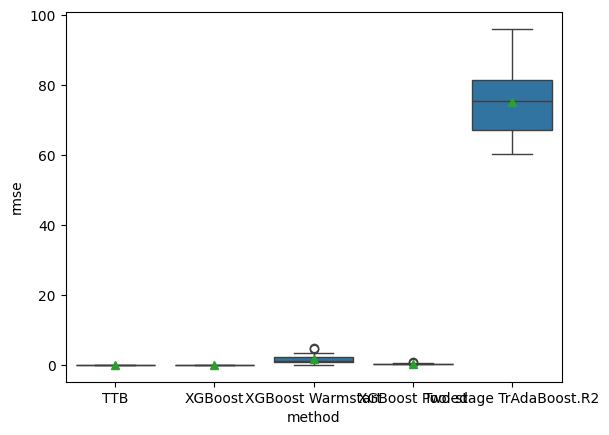

In [799]:
sub_name = 'height'

dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results_{sub_name}/xgb_naive.csv')
xgboost_data_pooled = data
xgboost_data_pooled ['method'] = 'XGBoost Pooled'

best_XGBoost_pooled , best_XGBoost_params_pooled  = topk_per_d_per_method(
    xgboost_data_pooled ,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_pooled['method'] = 'XGBoost Pooled'

data = pd.read_csv(f'results_{sub_name}/two_trada.csv')
trada_data = data
trada_data['method'] = 'two-stage TrAdaBoost.R2'

best_trada, best_trada_params = topk_per_d_per_method(
    trada_data,
['lr', 'n_estimators', 'tree_size'], k=nr_of_seeds
)
best_trada['method'] = 'Two-stage TrAdaBoost.R2'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])
df = pd.concat([df, best_XGBoost_pooled])
df = pd.concat([df, best_trada])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [800]:
#Obtain best parameters in order based on test rmse
dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=100000
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=100000
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=100000
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results_{sub_name}/xgb_naive.csv')
xgboost_data_pooled = data
xgboost_data_pooled ['method'] = 'XGBoost Pooled'

best_XGBoost_pooled , best_XGBoost_params_pooled  = topk_per_d_per_method(
    xgboost_data_pooled ,
['v', 'target_tree_size'], k=100000
)
best_XGBoost_pooled['method'] = 'XGBoost Pooled'

data = pd.read_csv(f'results_{sub_name}/two_trada.csv')
trada_data = data
trada_data['method'] = 'TrAdaBoost.R2'

best_trada, best_trada_params = topk_per_d_per_method(
    trada_data,
['lr', 'n_estimators', 'tree_size'], k=100000
)
best_trada['method'] = 'TrAdaBoost.R2'



C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_21944\517985385.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_21944\517985385.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_21944\517985385.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [801]:
#Get best params in order
best_LSTransferTreeBoost_params.iloc[::nr_of_seeds]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
1914,0.20,3.0,2.0,0.00,0.5,0.103492,0.074544,30,886.0,400.0,0.056342,0.045599,0.079997,0.062986,TransferTreeBoost
556,0.30,3.0,2.0,0.00,0.5,0.104322,0.074305,30,867.0,400.0,0.102950,0.076009,0.122706,0.084532,TransferTreeBoost
768,0.30,3.0,3.0,0.01,0.9,0.105310,0.076367,30,870.0,400.0,0.102822,0.073952,0.141015,0.093180,TransferTreeBoost
0,0.10,3.0,2.0,0.00,0.5,0.105457,0.076020,30,860.0,400.0,0.107760,0.087244,0.095483,0.082978,TransferTreeBoost
519,0.05,3.0,2.0,0.01,0.9,0.105566,0.076796,30,867.0,400.0,0.084887,0.064904,0.111400,0.077094,TransferTreeBoost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983,0.20,2.0,3.0,0.01,0.9,0.119604,0.088290,30,873.0,400.0,0.097747,0.078639,0.113368,0.086727,TransferTreeBoost
1709,0.05,1.0,3.0,0.01,0.9,0.120727,0.087916,30,883.0,400.0,0.142802,0.098298,0.124165,0.084450,TransferTreeBoost
184,0.10,1.0,3.0,0.01,0.9,0.120945,0.089166,30,862.0,400.0,0.152611,0.105380,0.083981,0.063603,TransferTreeBoost
2141,0.20,1.0,3.0,0.01,0.9,0.121500,0.090533,30,889.0,400.0,0.194646,0.134335,0.097893,0.068578,TransferTreeBoost


In [802]:
#Get best params in order
best_XGBoost_params.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
527,0.20,2.0,0.119331,0.084177,30,523,874.0,0.096745,0.075135,0.101410,0.076588,XGBoost
381,0.25,2.0,0.119600,0.083969,30,385,870.0,0.112254,0.073466,0.173595,0.115226,XGBoost
375,0.15,1.0,0.120101,0.085543,30,372,870.0,0.113426,0.080406,0.178573,0.118632,XGBoost
6,0.10,1.0,0.120186,0.084941,30,6,860.0,0.128682,0.097652,0.113932,0.086530,XGBoost
621,0.20,1.0,0.120506,0.085501,30,630,877.0,0.146496,0.105199,0.131831,0.090053,XGBoost
121,0.15,2.0,0.120536,0.085054,30,121,863.0,0.117902,0.069560,0.104913,0.077174,XGBoost
543,0.05,1.0,0.120621,0.085734,30,540,875.0,0.126312,0.089366,0.111870,0.079894,XGBoost
1067,0.10,2.0,0.120666,0.084813,30,1051,889.0,0.198598,0.128257,0.107711,0.068127,XGBoost
818,0.05,2.0,0.120897,0.085313,30,793,882.0,0.103484,0.077655,0.089431,0.071243,XGBoost
220,0.30,2.0,0.120902,0.085659,30,247,866.0,0.104150,0.072872,0.121949,0.086910,XGBoost


In [803]:
#Get best params in order
best_XGBoost_params_warmstart.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
0,0.050,1.0,1.695009,0.747914,30,0,860.0,2.032504,0.880015,1.096789,0.385835,XGBoost Warmstart
1198,0.050,3.0,1.836669,0.996548,30,1157,875.0,0.254739,0.125364,0.883939,0.314499,XGBoost Warmstart
743,0.050,2.0,1.860439,0.881163,30,694,869.0,0.489885,0.195956,1.155973,0.409987,XGBoost Warmstart
1509,0.075,1.0,1.997506,0.897688,30,1470,879.0,1.177100,0.590643,1.033110,0.546569,XGBoost Warmstart
1155,0.100,1.0,2.273285,1.023438,30,1169,875.0,1.251910,0.484729,1.099370,0.378512,XGBoost Warmstart
...,...,...,...,...,...,...,...,...,...,...,...,...
209,0.225,7.0,7.455262,4.989935,30,209,862.0,6.759522,3.885280,7.848684,5.264469,XGBoost Warmstart
57,0.250,7.0,7.602324,5.139939,30,62,860.0,8.951070,5.908683,8.692630,6.351104,XGBoost Warmstart
532,0.275,7.0,7.775305,5.255364,30,531,866.0,10.790384,6.744533,11.490541,7.818318,XGBoost Warmstart
1231,0.300,6.0,7.864417,5.353780,30,1230,875.0,6.164225,3.816838,8.997065,6.584631,XGBoost Warmstart


In [804]:
#Get best params in order
best_XGBoost_params_pooled.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
23,0.050,7.0,0.399213,0.333030,30,6,860.0,0.355767,0.304735,0.435384,0.359703,XGBoost Pooled
1184,0.100,7.0,0.443229,0.337132,30,1175,875.0,0.495170,0.323587,0.665751,0.481550,XGBoost Pooled
90,0.075,7.0,0.452838,0.349849,30,90,861.0,0.534317,0.408509,0.389882,0.305752,XGBoost Pooled
51,0.150,7.0,0.497890,0.344541,30,34,860.0,0.477789,0.303543,0.400368,0.248025,XGBoost Pooled
1007,0.050,6.0,0.510385,0.424996,30,1006,873.0,0.459152,0.410760,0.406704,0.356375,XGBoost Pooled
...,...,...,...,...,...,...,...,...,...,...,...,...
440,0.150,1.0,17.427039,15.879656,30,413,865.0,15.993091,14.110180,19.204759,18.133676,XGBoost Pooled
756,0.275,1.0,17.528169,15.797060,30,756,869.0,16.241362,14.631423,15.250341,13.593987,XGBoost Pooled
821,0.225,1.0,17.684971,16.115918,30,819,870.0,17.644462,15.726186,19.266604,18.149525,XGBoost Pooled
1597,0.300,1.0,17.744181,16.055593,30,1610,880.0,17.848312,16.161227,18.208536,16.147136,XGBoost Pooled


In [805]:
#Get best params in order
#best_trada_params.iloc[::nr_of_seeds]

In [806]:
((best_XGBoost_params.iloc[0]['avg_rmse'] - best_LSTransferTreeBoost_params.iloc[0]['avg_rmse']) / best_XGBoost_params.iloc[0]['avg_rmse'])*100

np.float64(13.272818016817677)

In [807]:
#Obtain best parameters in order based on test rmse
dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results_{sub_name}/two_trada.csv')
trada_data = data
trada_data['method'] = 'TrAdaBoost.R2'

best_trada, best_trada_params = topk_per_d_per_method(
    trada_data,
['lr', 'n_estimators', 'tree_size'], k=nr_of_seeds
)
best_trada['method'] = 'TrAdaBoost.R2'

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_21944\166682383.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_21944\166682383.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_21944\166682383.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [808]:
#Get best params in order
import numpy as np
print(
    np.round(best_LSTransferTreeBoost_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_LSTransferTreeBoost_params['rmse']), 3), "&",
    np.round(best_XGBoost_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params['rmse']), 3), "&",
    np.round(best_XGBoost_params_warmstart['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params_warmstart['rmse']), 3), "&",
    np.round(best_XGBoost_params_pooled['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params_pooled['rmse']), 3), "&",
    np.round(best_trada_params['avg_rmse'].iloc[0], 3),   "&",
    np.round(np.std(best_trada_params['rmse']), 3)
)

0.103 & 0.022 & 0.119 & 0.024 & 1.695 & 1.186 & 0.399 & 5.781 & 75.067 & 8.401
